# CAA Decomposition Steering Experiments

Tests whether the decomposition `c_e = (c_e · g)·g + resid_e` gives **better independent control**
over emotional expressiveness (`g`) and named-emotion identity (`resid_e`) than the original pooled
CAA vector alone.

## Steering conditions compared
| label | steering vector |
|---|---|
| `none` | no steering |
| `g` | common emotionalization direction |
| `resid_e` | emotion-specific residual |
| `g+resid_e` | both components |
| `original_caa_e` | original pooled CAA direction |
| `g+resid_e+PCk` | `g+resid_e` + local PC axis (Exp 4) |
| `g+resid_e-PCk` | `g+resid_e` - local PC axis (Exp 4) |

## Sections
1. Imports & Configuration
2. Decompose CAA vectors: g, resid_e, norms
3. Load dataset (held-out source texts)
4. Load model & tokenizer
5. Steering hook & generation utilities
6. Experiment 1 — Functional decomposition (qualitative side-by-side)
7. Experiment 2 — LLM evaluation batch file creation
8. Experiment 3 — Multiplier sweep (2D control surface)
9. Experiment 4 — Local PC steering within emotion
10. Experiment 5 — Prompt-only vs activation-steering baseline
11. Aggregate results & plots

## 1. Imports & Configuration

In [36]:
from __future__ import annotations

import gc
import json
import textwrap
import warnings
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import yaml
from tqdm import tqdm

warnings.filterwarnings('ignore', category=UserWarning)

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT    = Path('../..').resolve()
ACT_DIR      = REPO_ROOT / 'activation' / 'emotion_rewrites'
CAA_PATH     = ACT_DIR  / 'caa_emotion_directions.npz'
CAA_INFO     = ACT_DIR  / 'caa_emotion_directions_info.json'
EMO_NPY      = ACT_DIR  / 'emotion_intensity_residual_stream.npy'
EMO_INFO     = ACT_DIR  / 'emotion_intensity_residual_stream_info.json'
NEUTRAL_NPY  = ACT_DIR  / 'neutral_paraphrase_residual_stream.npy'
NEUTRAL_INFO = ACT_DIR  / 'neutral_paraphrase_residual_stream_info.json'
REWRITE_JSONL = REPO_ROOT / 'dataset' / 'emotion_rewrites' / 'emotion_rewrites.jsonl'
LOCAL_PC_DIR  = REPO_ROOT / 'analysis' / 'caa' / 'local_pc_interpretation'
OUT_DIR       = REPO_ROOT / 'analysis' / 'caa' / 'steering_decomposition'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Experiment run flags (set to True to enable each experiment) ───────────────
# Start with only Exp 1 enabled; enable others after confirming Exp 1 is correct.
RUN_EXP3 = True   # Multiplier sweep   (~2 000 generations)
RUN_EXP4 = True   # Local PC steering  (~3 300 generations + PCA refit)
RUN_EXP5 = True   # Prompt-only baseline (~1 400 generations)

# ── Configuration ─────────────────────────────────────────────────────────────
PRIMARY_LAYER    = 13         # transformer block (0-based)
DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'
# Keep MAX_EXAMPLES small for the first run — scale up after confirming correctness.
MAX_EXAMPLES     = 20         # held-out texts for Exp 1/2/3/5
MAX_PC_EXAMPLES  = 8          # texts for Exp 4 (each spawns many generations)
MAX_SRC_FOR_PCA  = 1500       # sources used to fit local PCA (Exp 4)
MAX_NEW_TOKENS   = 60
DO_SAMPLE        = False      # greedy decoding
SEED             = 42
K_LOCAL          = 5          # local PCs per emotion (Exp 4)
# Default multipliers
ALPHA_G_DEFAULT  = 3.0
ALPHA_R_DEFAULT  = 5.0
# Multiplier grid for Exp 3
G_SWEEP          = [0.0, 1.0, 2.5, 5.0, 8.0]
R_SWEEP          = [0.0, 1.0, 2.5, 5.0, 10.0]
PC_ALPHAS        = [2.0, 5.0, 8.0]
TOP_PCS          = 3           # PC1..PC3 for Exp 4
# Flush CUDA / GC every this many generations (prevents GPU memory fragmentation)
CACHE_FLUSH_EVERY = 20

rng = np.random.default_rng(SEED)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})

# ── RAM preflight ──────────────────────────────────────────────────────────────
import psutil as _psutil
_mem = _psutil.virtual_memory()
print(f'System RAM total    : {_mem.total / 1e9:.1f} GB')
print(f'System RAM available: {_mem.available / 1e9:.1f} GB')
if _mem.available < 8e9:
    print('⚠  WARNING: <8 GB free RAM. Set load_in_4bit: true in model.yaml before loading.')

print(f'\nDevice       : {DEVICE}')
print(f'Primary layer: {PRIMARY_LAYER}')
print(f'Output dir   : {OUT_DIR}')
print(f'\nGeneration counts (estimates):')
print(f'  Exp 1 : {MAX_EXAMPLES} texts × 8 emotions × 5 conditions = {MAX_EXAMPLES*8*5}')
print(f'  Exp 3 : {min(10,MAX_EXAMPLES)} texts × 8 × {len(G_SWEEP)}×{len(R_SWEEP)} = '
      f'{min(10,MAX_EXAMPLES)*8*len(G_SWEEP)*len(R_SWEEP)}  (RUN_EXP3={RUN_EXP3})')
print(f'  Exp 4 : {MAX_PC_EXAMPLES} texts × 8 × {TOP_PCS} PCs × {len(PC_ALPHAS)*2+1} = '
      f'{MAX_PC_EXAMPLES*8*TOP_PCS*(len(PC_ALPHAS)*2+1)}  (RUN_EXP4={RUN_EXP4})')
print(f'  Exp 5 : {MAX_EXAMPLES} texts × 8 × 3 = {MAX_EXAMPLES*8*3}  (RUN_EXP5={RUN_EXP5})')


System RAM total    : 33.5 GB
System RAM available: 25.4 GB

Device       : cuda
Primary layer: 13
Output dir   : /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition

Generation counts (estimates):
  Exp 1 : 20 texts × 8 emotions × 5 conditions = 800
  Exp 3 : 10 texts × 8 × 5×5 = 2000  (RUN_EXP3=True)
  Exp 4 : 8 texts × 8 × 3 PCs × 7 = 1344  (RUN_EXP4=True)
  Exp 5 : 20 texts × 8 × 3 = 480  (RUN_EXP5=True)


## 2. Decompose CAA Vectors: g, resid_e, norms

$$
g = \frac{1}{|\mathcal{E}|} \sum_e \hat{c}_e
\qquad
\hat{g} = \frac{g}{\|g\|}
\qquad
\mathrm{resid}_e = c_e - (c_e \cdot \hat{g})\,\hat{g}
$$

where `c_e = caa_pooled[e, layer_idx, :]` is the *already unit-normalised* pooled CAA vector.

> **Note on scaling:** `caa_pooled` vectors are unit-normalised at save time (per the info JSON).
> We record raw norms of `g` and `resid_e` to understand natural magnitudes, and always apply
> explicit multipliers (alpha_g, alpha_r) at generation time.

In [2]:
# ── Load CAA metadata ─────────────────────────────────────────────────────────
with open(CAA_INFO) as f:
    caa_meta = json.load(f)

EMOTION_ORDER  : list[str] = caa_meta['emotion_order']
INTENSITY_ORDER: list[str] = caa_meta['intensity_order']
LAYER_INDICES  : list[int] = caa_meta['layer_indices']
N_EMO = len(EMOTION_ORDER)
LI    = LAYER_INDICES.index(PRIMARY_LAYER)   # index into layer axis

caa_data   = np.load(CAA_PATH)
# caa_pooled[e, l, :] — unit normalised per description
caa_pooled = caa_data['caa_pooled']   # (N_EMO, N_LAY, D)
D = caa_pooled.shape[-1]

print(f'caa_pooled shape  : {caa_pooled.shape}  (N_EMO, N_LAY, D)')
print(f'Emotions          : {EMOTION_ORDER}')
print(f'Layer indices     : {LAYER_INDICES}  →  using LI={LI} (layer {PRIMARY_LAYER})')
print(f'D                 : {D}')

# ── Extract C at PRIMARY_LAYER ────────────────────────────────────────────────
C = caa_pooled[:, LI, :].copy().astype(np.float32)   # (N_EMO, D), already unit-norm

# ── Compute common emotionalization direction g ────────────────────────────────
def unit(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + 1e-12)

g_raw = C.mean(axis=0)         # (D,)
g     = unit(g_raw)            # unit-norm

# ── Residualize each emotion CAA vector ───────────────────────────────────────
proj_onto_g = (C @ g)[..., None]           # (N_EMO, 1)
resid_raw   = C - proj_onto_g * g          # (N_EMO, D)  — natural scale
resid_unit  = unit(resid_raw)              # (N_EMO, D)  — unit-normalised

# ── Report norms ──────────────────────────────────────────────────────────────
print(f'\n||g_raw||               = {np.linalg.norm(g_raw):.4f}')
print(f'||g|| (unit)            = {np.linalg.norm(g):.4f}')
print()
print(f'{"emotion":<14} {"||c_e||":>8} {"c_e·g":>8} {"||resid_raw||":>14} {"||resid_unit||":>14}')
print('─' * 58)
for ei, emo in enumerate(EMOTION_ORDER):
    ce_norm    = np.linalg.norm(C[ei])
    dot_with_g = float(C[ei] @ g)
    r_norm     = np.linalg.norm(resid_raw[ei])
    ru_norm    = np.linalg.norm(resid_unit[ei])
    print(f'{emo:<14} {ce_norm:>8.4f} {dot_with_g:>8.4f} {r_norm:>14.4f} {ru_norm:>14.4f}')

print()
print('Vectors ready: g (unit), C (unit, per-emotion), resid_raw (natural), resid_unit (unit)')

caa_pooled shape  : (8, 6, 4096)  (N_EMO, N_LAY, D)
Emotions          : ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
Layer indices     : [8, 10, 13, 16, 19, 22]  →  using LI=2 (layer 13)
D                 : 4096

||g_raw||               = 0.9937
||g|| (unit)            = 1.0000

emotion         ||c_e||    c_e·g  ||resid_raw|| ||resid_unit||
──────────────────────────────────────────────────────────
joy              1.0000   0.9923         0.1237         1.0000
trust            1.0000   0.9917         0.1282         1.0000
fear             1.0000   0.9946         0.1035         1.0000
surprise         1.0000   0.9908         0.1353         1.0000
sadness          1.0000   0.9965         0.0834         1.0000
disgust          1.0000   0.9954         0.0961         1.0000
anger            1.0000   0.9941         0.1089         1.0000
anticipation     1.0000   0.9942         0.1080         1.0000

Vectors ready: g (unit), C (unit, per-emotion), resid_

## 3. Load Dataset (Held-Out Source Texts)

We load base texts from the emotion rewrites JSONL. We deduplicate by `source_id` (keeping one row per
source, preferring `intensity_level == 'medium'`), then sample `MAX_EXAMPLES` held-out texts.

In [3]:
# ── Load all rows ─────────────────────────────────────────────────────────────
records_raw: list[dict] = []
with open(REWRITE_JSONL) as f:
    for line in f:
        records_raw.append(json.loads(line))

print(f'Total rows in JSONL: {len(records_raw)}')

# ── Deduplicate by source_id, keep medium intensity ──────────────────────────
seen_ids: set[str] = set()
source_records: list[dict] = []
for rec in records_raw:
    sid = rec.get('source_id', '')
    if sid and sid not in seen_ids and rec.get('intensity_level', '') == 'medium':
        seen_ids.add(sid)
        source_records.append(rec)

# fallback: if medium not available, accept all
if len(source_records) < 10:
    seen_ids = set()
    source_records = []
    for rec in records_raw:
        sid = rec.get('source_id', '')
        if sid and sid not in seen_ids:
            seen_ids.add(sid)
            source_records.append(rec)

print(f'Unique source_ids (medium): {len(source_records)}')

# ── Sample held-out texts ─────────────────────────────────────────────────────
sample_size = min(MAX_EXAMPLES, len(source_records))
idx_sample  = rng.choice(len(source_records), size=sample_size, replace=False)
held_out    = [source_records[i] for i in sorted(idx_sample)]

# Build lookup: source_id → {base_text, emotion_rewrites, ...}
def extract_rewrites(rec: dict) -> dict[str, str]:
    return {emo: rec[f'{emo}_rewrite'] for emo in EMOTION_ORDER if f'{emo}_rewrite' in rec}

print(f'\nHeld-out sample size: {len(held_out)}')
print('Example record:')
ex = held_out[0]
print(f'  source_id : {ex["source_id"]}')
print(f'  base_text : {ex["base_text"][:100]!r}')
print(f'  rewrites  : {list(extract_rewrites(ex).keys())}')

Total rows in JSONL: 68346
Unique source_ids (medium): 22782

Held-out sample size: 20
Example record:
  source_id : ed_all_32748
  base_text : 'i felt bad when i couldnt get my daughter what she wanted'
  rewrites  : ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']


## 4. Load Model & Tokenizer

In [4]:
import psutil
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

with open(REPO_ROOT / 'model.yaml') as f:
    model_cfg = yaml.safe_load(f)

MODEL_NAME  = model_cfg['name']
DTYPE_MAP   = {'bfloat16': torch.bfloat16, 'float16': torch.float16, 'float32': torch.float32}
MODEL_DTYPE = DTYPE_MAP.get(model_cfg.get('dtype', 'bfloat16'), torch.bfloat16)
ATTN_IMPL   = model_cfg.get('attn_implementation', 'sdpa')
USE_4BIT    = model_cfg.get('load_in_4bit', False)

# ── RAM preflight before loading ──────────────────────────────────────────────
_n_params_approx  = 8e9   # Llama-3.1-8B
_bytes_per_param  = 0.5 if USE_4BIT else (2 if MODEL_DTYPE in (torch.bfloat16, torch.float16) else 4)
_model_est_gb     = _n_params_approx * _bytes_per_param / 1e9
_avail_gb         = psutil.virtual_memory().available / 1e9
print(f'Model : {MODEL_NAME}')
print(f'dtype : {MODEL_DTYPE}  attn={ATTN_IMPL}  4bit={USE_4BIT}')
print(f'Estimated model size : ~{_model_est_gb:.1f} GB')
print(f'Available RAM        :  {_avail_gb:.1f} GB')
if _avail_gb < _model_est_gb + 4.0:
    print('⚠  WARNING: tight on RAM.')
    print('   → Set  load_in_4bit: true  in model.yaml to reduce to ~4 GB.')
    print('   → Or close other large processes before continuing.')

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = 'left'
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# ── Model ─────────────────────────────────────────────────────────────────────
bnb_cfg = None
if USE_4BIT:
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
    )

print('Loading model…')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=MODEL_DTYPE,
    attn_implementation=ATTN_IMPL,
    device_map='auto',
    low_cpu_mem_usage=True,
    quantization_config=bnb_cfg,
 )
model.eval()
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

_rss_after = psutil.Process().memory_info().rss / 1e9
print(f'Loaded. d_model={model.config.hidden_size}  n_layers={model.config.num_hidden_layers}')
print(f'Process RSS after load: {_rss_after:.1f} GB  '
      f'(RAM remaining: {psutil.virtual_memory().available / 1e9:.1f} GB)')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        _used = torch.cuda.memory_allocated(i) / 1e9
        _total = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i}: {_used:.1f} / {_total:.1f} GB used')

assert PRIMARY_LAYER < model.config.num_hidden_layers


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model : meta-llama/Llama-3.1-8B-Instruct
dtype : torch.bfloat16  attn=sdpa  4bit=False
Estimated model size : ~16.0 GB
Available RAM        :  26.9 GB
Loading model…


Loading weights: 100%|██████████| 291/291 [00:02<00:00, 115.85it/s]


Loaded. d_model=4096  n_layers=32
Process RSS after load: 1.5 GB  (RAM remaining: 26.6 GB)
  GPU 0: 16.1 / 25.8 GB used


## 5. Steering Hook & Generation Utilities

The hook adds `alpha * unit(vec)` to the **last token** position in the residual stream output
of the target transformer block on every forward pass during `model.generate()`.

Multiple vectors can be composed by passing a list of `(vec, alpha)` pairs.

In [5]:
# ── Prompt templates ──────────────────────────────────────────────────────────
from emotionengine.text_utils import INSTRUCTION_TEMPLATE, make_instruction_prefix

EMOTION_INSTRUCTION_TEMPLATE = (
    "Please rewrite this to strongly express {emotion}.\n"
    "Start straight from the rewritten text without any preamble, and only provide **one** rewritten version.\n"
    "Base: {base}\n\n"
)

# ── Context-manager hook ───────────────────────────────────────────────────────
@contextmanager
def steer_at_layer(
    steer_model: AutoModelForCausalLM,
    layer_idx: int,
    components: list[tuple[np.ndarray | torch.Tensor, float]],
):
    """
    Register a hook that adds sum_i(alpha_i * unit(vec_i)) to the last token
    of the residual stream at block `layer_idx`.

    components: list of (vec, alpha) pairs.
                vec is unit-normalised inside this function so alpha is always
                in 'unit-vector scale' units.
    The delta tensor is built once, kept on device for the duration of generation,
    and freed when the context exits.
    """
    layer_module  = steer_model.model.layers[layer_idx]
    layer_device  = next(layer_module.parameters()).device
    target_dtype  = next(layer_module.parameters()).dtype

    delta = torch.zeros(D, dtype=target_dtype, device=layer_device)
    for vec, alpha in components:
        t = torch.from_numpy(vec.copy()) if isinstance(vec, np.ndarray) else vec.clone()
        t = t.to(dtype=target_dtype, device=layer_device)
        t = t / (t.norm() + 1e-10)
        delta = delta + alpha * t
    delta = delta.reshape(1, 1, -1)  # (1, 1, D)

    def _hook(*args):
        out = args[2]
        hidden = out[0] if isinstance(out, tuple) else out
        rest   = out[1:] if isinstance(out, tuple) else None
        hidden = hidden.clone()
        hidden[:, -1:, :] = hidden[:, -1:, :] + delta
        return (hidden, *rest) if rest is not None else hidden

    handle = layer_module.register_forward_hook(_hook)
    try:
        yield
    finally:
        handle.remove()
        del delta   # free device tensor immediately when hook is removed


def inspect_steering_scale(
    base_text: str,
    components: list[tuple[np.ndarray | torch.Tensor, float]],
    layer_idx: int = PRIMARY_LAYER,
    prompt_emotion: str | None = None,
) -> dict[str, float]:
    """Measure injected delta norm relative to the target layer hidden norm."""
    if not components:
        return {
            'hidden_norm': float('nan'),
            'delta_norm': 0.0,
            'delta_over_hidden': 0.0,
            'prompt_tokens': 0,
        }

    prompt = make_instruction_prefix(base_text, tokenizer)
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    layer_module = model.model.layers[layer_idx]
    layer_device = next(layer_module.parameters()).device
    layer_dtype  = next(layer_module.parameters()).dtype

    delta = torch.zeros(D, dtype=layer_dtype, device=layer_device)
    for vec, alpha in components:
        t = torch.from_numpy(vec.copy()) if isinstance(vec, np.ndarray) else vec.clone()
        t = t.to(dtype=layer_dtype, device=layer_device)
        t = t / (t.norm() + 1e-10)
        delta = delta + alpha * t

    stats: dict[str, float] = {}

    def _probe_hook(*args):
        out = args[2]
        hidden = out[0] if isinstance(out, tuple) else out
        last_hidden = hidden[:, -1, :].detach().to(layer_device)
        stats['hidden_norm'] = float(last_hidden.norm().item())
        stats['delta_norm'] = float(delta.norm().item())
        stats['delta_over_hidden'] = stats['delta_norm'] / max(stats['hidden_norm'], 1e-8)
        stats['prompt_tokens'] = int(hidden.shape[1])

    handle = layer_module.register_forward_hook(_probe_hook)
    try:
        with torch.inference_mode():
            model(**inputs, use_cache=False)
    finally:
        handle.remove()
        del inputs, delta

    return stats


def resid_raw_norm(emotion_idx: int) -> float:
    return float(np.linalg.norm(resid_raw[emotion_idx]))


def effective_resid_alpha(
    emotion_idx: int,
    alpha_r: float,
    use_unit_resid: bool = False,
) -> float:
    """Return the actual injected residual strength after the notebook's scaling rule."""
    return alpha_r if use_unit_resid else alpha_r * resid_raw_norm(emotion_idx)


def alpha_r_for_effective_resid(
    emotion_idx: int,
    target_effective_alpha: float,
) -> float:
    """Invert the natural-scale rule so the caller can request a real residual strength."""
    return target_effective_alpha / max(resid_raw_norm(emotion_idx), 1e-12)


def _flush_device_cache() -> None:
    """Free cached GPU memory and trigger Python GC. Call every N generations."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Generation counter used for periodic cache flushing
_gen_counter = 0

def generate_steered(
    base_text: str,
    components: list[tuple[np.ndarray, float]] | None = None,
    layer_idx: int = PRIMARY_LAYER,
    max_new_tokens: int = MAX_NEW_TOKENS,
    prompt_emotion: str | None = None,
) -> str:
    """
    Generate a rewrite with optional activation steering.

    components: list of (vec, alpha); None or [] means no steering.
    prompt_emotion: if set, uses the emotion-specific prompt template (Exp 5).
    Returns the decoded generated text (no prompt prefix).

    Memory discipline:
    - Input/output tensors are explicitly deleted before return.
    - Device cache is flushed every CACHE_FLUSH_EVERY calls.
    """
    global _gen_counter
    tmpl = EMOTION_INSTRUCTION_TEMPLATE.replace('{emotion}', prompt_emotion) if prompt_emotion else INSTRUCTION_TEMPLATE
    prompt = make_instruction_prefix(base_text, tokenizer, template=tmpl)
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=DO_SAMPLE,
        pad_token_id=tokenizer.pad_token_id,
    )

    try:
        with torch.inference_mode():
            if components:
                with steer_at_layer(model, layer_idx, components):
                    out_ids = model.generate(**inputs, **gen_kwargs)
            else:
                out_ids = model.generate(**inputs, **gen_kwargs)

        new_ids = out_ids[0, inputs['input_ids'].shape[1]:]
        result  = tokenizer.decode(
            new_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        ).strip()
    except torch.cuda.OutOfMemoryError:
        _flush_device_cache()
        print(f'\n⚠  CUDA OOM on call {_gen_counter} — flushing cache and returning empty string.')
        result = '[OOM]'
    finally:
        # Always free device tensors, even on exception
        del inputs
        if 'out_ids' in locals():
            del out_ids

    _gen_counter += 1
    if _gen_counter % CACHE_FLUSH_EVERY == 0:
        _flush_device_cache()

    return result


# ── Convenience builder for decomposed steering conditions ─────────────────────
def make_components(
    condition: str,
    emotion_idx: int,
    alpha_g: float = ALPHA_G_DEFAULT,
    alpha_r: float = ALPHA_R_DEFAULT,
    use_unit_resid: bool = False,
    pc_vec: np.ndarray | None = None,
    alpha_pc: float = 0.0,
) -> list[tuple[np.ndarray, float]]:
    """
    Build the component list for a named steering condition.

    Because the hook re-normalises every vector, `use_unit_resid=False` does not
    change the residual direction. It only shrinks the effective residual strength
    to `alpha_r * ||resid_raw||`, which is usually about 0.1x of alpha_r here.

    Conditions: none, g, resid, g+resid, original_caa, g+resid+pc, g+resid-pc
    """
    if use_unit_resid:
        r_vec   = resid_unit[emotion_idx]
        r_alpha = alpha_r
    else:
        r_vec   = resid_raw[emotion_idx]
        r_alpha = effective_resid_alpha(emotion_idx, alpha_r, use_unit_resid=False)

    if condition == 'none':
        return []
    elif condition == 'g':
        return [(g, alpha_g)]
    elif condition == 'resid':
        return [(r_vec, r_alpha)]
    elif condition == 'g+resid':
        return [(g, alpha_g), (r_vec, r_alpha)]
    elif condition == 'original_caa':
        return [(C[emotion_idx], alpha_g)]
    elif condition == 'g+resid+pc':
        assert pc_vec is not None
        return [(g, alpha_g), (r_vec, r_alpha), (pc_vec, alpha_pc)]
    elif condition == 'g+resid-pc':
        assert pc_vec is not None
        return [(g, alpha_g), (r_vec, r_alpha), (pc_vec, -alpha_pc)]
    else:
        raise ValueError(f'Unknown condition: {condition}')


print('Steering utilities ready.')
print(f'Prompt template (generic): {INSTRUCTION_TEMPLATE[:80]!r}…')
print('Natural residual mode injects alpha_r * ||resid_raw||, not alpha_r itself.')
print(f'Cache flush every {CACHE_FLUSH_EVERY} generations.')


Steering utilities ready.
Prompt template (generic): 'Please rewrite this so it aligns with my feelings more.\nStart straight from the '…
Natural residual mode injects alpha_r * ||resid_raw||, not alpha_r itself.
Cache flush every 20 generations.


In [6]:
# ── Focused diagnostic: one text, compare steering scale vs hidden norm ────────
DIAG_TEXT = 'i felt bad when i couldnt get my daughter what she wanted'
DIAG_VARIANTS = [
    ('joy / original_caa @ (3.0)', 'joy', make_components('original_caa', EMOTION_ORDER.index('joy'), alpha_g=3.0), None),
    ('joy / g+resid_raw @ (3.0, 5.0)', 'joy', make_components('g+resid', EMOTION_ORDER.index('joy'), alpha_g=3.0, alpha_r=5.0, use_unit_resid=False), 5.0),
    ('joy / g+resid_raw matched to eff=3.0', 'joy', make_components('g+resid', EMOTION_ORDER.index('joy'), alpha_g=3.0, alpha_r=alpha_r_for_effective_resid(EMOTION_ORDER.index('joy'), 3.0), use_unit_resid=False), alpha_r_for_effective_resid(EMOTION_ORDER.index('joy'), 3.0)),
    ('joy / g+resid_unit @ (3.0, 3.0)', 'joy', make_components('g+resid', EMOTION_ORDER.index('joy'), alpha_g=3.0, alpha_r=3.0, use_unit_resid=True), 3.0),
    ('trust / g+resid_raw @ (3.0, 5.0)', 'trust', make_components('g+resid', EMOTION_ORDER.index('trust'), alpha_g=3.0, alpha_r=5.0, use_unit_resid=False), 5.0),
    ('fear / g+resid_raw @ (3.0, 5.0)', 'fear', make_components('g+resid', EMOTION_ORDER.index('fear'), alpha_g=3.0, alpha_r=5.0, use_unit_resid=False), 5.0),
]

print(textwrap.shorten(DIAG_TEXT, width=90))
for label, emo, comps, alpha_r_raw in DIAG_VARIANTS:
    ei = EMOTION_ORDER.index(emo)
    stats = inspect_steering_scale(DIAG_TEXT, comps)
    out = generate_steered(DIAG_TEXT, components=comps)
    norm_r = resid_raw_norm(ei)
    eff_r = None if alpha_r_raw is None else effective_resid_alpha(ei, alpha_r_raw, use_unit_resid='unit' in label)
    print(label)
    print(
        f'    resid_norm={norm_r:.4f}  '
        f'raw_alpha_r={alpha_r_raw if alpha_r_raw is not None else 0.0:.3f}  '
        f'effective_alpha_r={eff_r if eff_r is not None else 0.0:.3f}'
    )
    print(
        f'    delta={stats["delta_norm"]:.3f}  '
        f'hidden={stats["hidden_norm"]:.3f}  '
        f'ratio={stats["delta_over_hidden"]:.3%}'
    )
    print(f'    {textwrap.shorten(out, width=160)}')
_flush_device_cache()


i felt bad when i couldnt get my daughter what she wanted
joy / original_caa @ (3.0)
    resid_norm=0.1237  raw_alpha_r=0.000  effective_alpha_r=0.000
    delta=3.000  hidden=7.469  ratio=40.167%
    As I stood there, watching my little one's face fall as she couldn't get her heart's desire, a pang of guilt and disappointment washed over me, a reminder [...]
joy / g+resid_raw @ (3.0, 5.0)
    resid_norm=0.1237  raw_alpha_r=5.000  effective_alpha_r=0.618
    delta=3.062  hidden=7.469  ratio=41.004%
    As I stood there, watching my little one's face fall as she couldn't get her heart's desire, a pang of sadness washed over me, a deep regret that I [...]
joy / g+resid_raw matched to eff=3.0
    resid_norm=0.1237  raw_alpha_r=24.259  effective_alpha_r=3.000
    delta=4.250  hidden=7.469  ratio=56.904%
    I felt a pang of disappointment when I was unable to surprise my little one with the toy she had been eyeing, and it was wonderful to see the sparkle in [...]
joy / g+resid_unit @ (3.0, 

## 6. Experiment 1 — Functional Decomposition

For each held-out source text and each target emotion, generate under all five conditions:
`none`, `g`, `resid`, `g+resid`, `original_caa`.

Saves `generation_outputs.jsonl` and prints a side-by-side comparison for a small inspection sample.

In [7]:
EXP1_CONDITIONS = ['none', 'g', 'resid', 'g+resid', 'original_caa']
EXP1_EMOTIONS   = EMOTION_ORDER   # all 8

GENERATION_OUTFILE = OUT_DIR / 'generation_outputs.jsonl'
EXP1_BATCH_SIZE    = 4   # texts per forward pass; reduce if OOM

exp1_rows: list[dict] = []

total_gens = len(held_out) * len(EXP1_EMOTIONS) * len(EXP1_CONDITIONS)
print(f'Total generations: {total_gens}  '
      f'({len(held_out)} texts × {len(EXP1_EMOTIONS)} emotions × {len(EXP1_CONDITIONS)} conditions)')
print(f'Batch size: {EXP1_BATCH_SIZE}  '
      f'Estimated time at ~2 s/gen: ~{total_gens * 2 / 60 / EXP1_BATCH_SIZE:.0f} min (batched)')

gen_kwargs = dict(
    max_new_tokens=MAX_NEW_TOKENS,
    do_sample=DO_SAMPLE,
    pad_token_id=tokenizer.pad_token_id,
)

with tqdm(total=total_gens, desc='Exp 1') as pbar:
    for emo in EXP1_EMOTIONS:
        ei = EMOTION_ORDER.index(emo)
        for cond in EXP1_CONDITIONS:
            comps = make_components(cond, ei, alpha_g=ALPHA_G_DEFAULT, alpha_r=ALPHA_R_DEFAULT)
            # Process all texts for this (emotion, condition) in batches
            for batch_start in range(0, len(held_out), EXP1_BATCH_SIZE):
                batch = held_out[batch_start : batch_start + EXP1_BATCH_SIZE]
                base_texts = [rec['base_text'].strip() for rec in batch]
                prompts    = [make_instruction_prefix(t, tokenizer) for t in base_texts]
                inputs     = tokenizer(
                    prompts,
                    return_tensors='pt',
                    padding=True,
                    truncation=True,
                ).to(model.device)
                prompt_width = inputs['input_ids'].shape[1]
                try:
                    with torch.inference_mode():
                        if comps:
                            with steer_at_layer(model, PRIMARY_LAYER, comps):
                                out_ids = model.generate(**inputs, **gen_kwargs)
                        else:
                            out_ids = model.generate(**inputs, **gen_kwargs)
                    for i, rec in enumerate(batch):
                        new_ids = out_ids[i, prompt_width:]
                        gen = tokenizer.decode(
                            new_ids,
                            skip_special_tokens=True,
                            clean_up_tokenization_spaces=False,
                        ).strip()
                        row = {
                            'source_id':          rec['source_id'],
                            'base_text':          base_texts[i],
                            'target_emotion':     emo,
                            'steering_condition': cond,
                            'layer':              PRIMARY_LAYER,
                            'alpha_g':            ALPHA_G_DEFAULT if 'g' in cond else 0.0,
                            'alpha_resid':        ALPHA_R_DEFAULT if 'resid' in cond else 0.0,
                            'generated_text':     gen,
                        }
                        exp1_rows.append(row)
                except torch.cuda.OutOfMemoryError:
                    _flush_device_cache()
                    print(f'\n⚠  OOM on ({emo}, {cond}) batch {batch_start} — filling with [OOM]')
                    for rec, bt in zip(batch, base_texts):
                        exp1_rows.append({
                            'source_id':          rec['source_id'],
                            'base_text':          bt,
                            'target_emotion':     emo,
                            'steering_condition': cond,
                            'layer':              PRIMARY_LAYER,
                            'alpha_g':            ALPHA_G_DEFAULT if 'g' in cond else 0.0,
                            'alpha_resid':        ALPHA_R_DEFAULT if 'resid' in cond else 0.0,
                            'generated_text':     '[OOM]',
                        })
                finally:
                    del inputs
                    if 'out_ids' in locals():
                        del out_ids
                pbar.update(len(batch))
            _flush_device_cache()

# ── Save ───────────────────────────────────────────────────────────────────────
with open(GENERATION_OUTFILE, 'w') as f:
    for row in exp1_rows:
        f.write(json.dumps(row, ensure_ascii=False) + '\n')

gen_df = pd.DataFrame(exp1_rows)
print(f'Saved {len(exp1_rows)} rows → {GENERATION_OUTFILE}')
_flush_device_cache()


Total generations: 800  (20 texts × 8 emotions × 5 conditions)
Batch size: 4  Estimated time at ~2 s/gen: ~7 min (batched)


Exp 1: 100%|██████████| 800/800 [06:52<00:00,  1.94it/s]


Saved 800 rows → /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition/generation_outputs.jsonl


In [8]:
# ── Side-by-side inspection — first 3 texts, first 3 emotions ─────────────────
INSPECT_EMOTIONS = EXP1_EMOTIONS[:3]
INSPECT_TEXTS    = [held_out[i]['base_text'].strip() for i in range(min(3, len(held_out)))]

for base in INSPECT_TEXTS:
    for emo in INSPECT_EMOTIONS:
        print(f'\n{"═"*72}')
        print(f'Source: {textwrap.shorten(base, 80)}')
        print(f'Target emotion: {emo}')
        print(f'{"─"*72}')
        subset = gen_df[(gen_df['base_text'] == base) & (gen_df['target_emotion'] == emo)]
        for _, row in subset.iterrows():
            label = f'  [{row["steering_condition"]:>14}]'
            out   = textwrap.shorten(row['generated_text'], 120)
            print(f'{label}  {out}')


════════════════════════════════════════════════════════════════════════
Source: i felt bad when i couldnt get my daughter what she wanted
Target emotion: joy
────────────────────────────────────────────────────────────────────────
  [          none]  The ache of disappointment still lingers when I'm unable to give my daughter the things she desires, a painful [...]
  [             g]  As I stood there, watching my little one's face fall as she couldn't get her heart's desire, a pang of guilt and [...]
  [         resid]  As I watched my daughter's face fall, her eyes welling up with disappointment, I couldn't help but feel a pang of [...]
  [       g+resid]  As I stood there, watching my little one's face fall as she couldn't get her heart's desire, a pang of sadness [...]
  [  original_caa]  As I stood there, watching my little one's face fall as she couldn't get her heart's desire, a pang of guilt and [...]

════════════════════════════════════════════════════════════════════════
S

## 7. Experiment 2 — LLM Evaluation Batch File

Creates `generation_eval_requests.jsonl` for OpenAI Batch API evaluation.

Each request asks an LLM to rate one generated output along three dimensions:
- `meaning_preserved` 0–1
- `emotionality` 0–1
- `target_emotion_match` 0–1
- `dominant_emotion` (named emotion or neutral/other)
- `notes` (brief explanation)

In [22]:
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.submit_openai_batch import submit_batch_file, summarize_jsonl

EVAL_SYSTEM_PROMPT = """You are an expert evaluator of emotional text rewrites.
Rate the output along three dimensions (each 0.0–1.0) and identify the dominant emotion.

Scoring rubric:
- meaning_preserved: 1.0 = core meaning fully retained; 0.0 = meaning changed completely
- emotionality: 1.0 = highly emotionally expressive; 0.0 = completely neutral/flat
- target_emotion_match: 1.0 = clearly expresses the target emotion; 0.0 = no match

Respond ONLY with valid JSON matching this schema:
{"meaning_preserved": float, "emotionality": float, "target_emotion_match": float,
 "dominant_emotion": "joy|trust|fear|surprise|sadness|disgust|anger|anticipation|neutral|other",
 "notes": "brief explanation"}"""

EVAL_USER_TEMPLATE = """Original text:
{base_text}

Target emotion: {target_emotion}

Generated rewrite:
{generated_text}

Rate the generated rewrite."""

EVAL_REQUESTS_FILE   = OUT_DIR / 'generation_eval_requests.jsonl'
EVAL_META_FILE       = OUT_DIR / 'generation_eval_meta.jsonl'
EVAL_RESULTS_FILE    = OUT_DIR / 'generation_eval_results.jsonl'
EVAL_SUBMISSION_FILE = OUT_DIR / 'generation_eval_batch_submission.json'
SUBMIT_EVAL_BATCH    = False

# ── Build batch requests ───────────────────────────────────────────────────────
eval_requests: list[dict] = []
for i, row in enumerate(exp1_rows):
    user_msg = EVAL_USER_TEMPLATE.format(
        base_text      = row['base_text'],
        target_emotion = row['target_emotion'],
        generated_text = row['generated_text'],
    )
    eval_requests.append({
        'custom_id': f'exp1_{i:05d}',
        'method': 'POST',
        'url': '/v1/chat/completions',
        'body': {
            'model': 'gpt-4o-mini',
            'messages': [
                {'role': 'system', 'content': EVAL_SYSTEM_PROMPT},
                {'role': 'user',   'content': user_msg},
            ],
            'response_format': {'type': 'json_object'},
            'temperature': 0,
        },
        # _meta stored separately — OpenAI Batch API does not accept unknown top-level fields
    })

# Write API requests (no _meta)
with open(EVAL_REQUESTS_FILE, 'w') as f:
    for req in eval_requests:
        f.write(json.dumps(req, ensure_ascii=False) + '\n')

# Write metadata separately, keyed by custom_id for later join
with open(EVAL_META_FILE, 'w') as f:
    for i, row in enumerate(exp1_rows):
        meta = {
            'custom_id':          f'exp1_{i:05d}',
            'source_id':          row['source_id'],
            'target_emotion':     row['target_emotion'],
            'steering_condition': row['steering_condition'],
            'layer':              row['layer'],
            'alpha_g':            row['alpha_g'],
            'alpha_resid':        row['alpha_resid'],
        }
        f.write(json.dumps(meta, ensure_ascii=False) + '\n')

summary = summarize_jsonl(EVAL_REQUESTS_FILE)
print(f'Wrote {len(eval_requests)} eval requests → {EVAL_REQUESTS_FILE}')
print(f'Wrote metadata → {EVAL_META_FILE}')
print(json.dumps(summary, indent=2, ensure_ascii=False))

if SUBMIT_EVAL_BATCH:
    submission = submit_batch_file(
        EVAL_REQUESTS_FILE,
        description='CAA decomposition steering Exp 1 evaluation',
        metadata={
            'notebook': 'caa_decomposition_steering',
            'experiment': 'exp1_eval',
        },
    )
    with open(EVAL_SUBMISSION_FILE, 'w') as f:
        json.dump(submission, f, indent=2, ensure_ascii=False)
    print(f"Submitted batch → {submission['batch_id']} (status={submission['status']})")
    print(f'Submission metadata → {EVAL_SUBMISSION_FILE}')
else:
    print('Submission disabled. Set SUBMIT_EVAL_BATCH = True in this cell to upload from the notebook.')
    print(
        'CLI alternative: '
        f'python scripts/submit_openai_batch.py submit {EVAL_REQUESTS_FILE} '
        '--description "CAA decomposition steering Exp 1 evaluation"'
    )


Wrote 800 eval requests → /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition/generation_eval_requests.jsonl
Wrote metadata → /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition/generation_eval_meta.jsonl
{
  "path": "/home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition/generation_eval_requests.jsonl",
  "requests": 800,
  "size_bytes": 1113246,
  "first_custom_id": "exp1_00000"
}
Submission disabled. Set SUBMIT_EVAL_BATCH = True in this cell to upload from the notebook.
CLI alternative: python scripts/submit_openai_batch.py submit /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition/generation_eval_requests.jsonl --description "CAA decomposition steering Exp 1 evaluation"


In [24]:
# ── Parse eval results (run after batch completes) ────────────────────────────
# Skip this cell if eval_results not yet available.
if not EVAL_RESULTS_FILE.exists():
    print(f'{EVAL_RESULTS_FILE} not found — skipping eval result parsing.')
    eval_df = None
else:
    # Load metadata keyed by custom_id
    meta_lookup: dict[str, dict] = {}
    if EVAL_META_FILE.exists():
        with open(EVAL_META_FILE) as f:
            for line in f:
                m = json.loads(line)
                meta_lookup[m['custom_id']] = m

    eval_rows = []
    with open(EVAL_RESULTS_FILE) as f:
        for line in f:
            result = json.loads(line)
            custom_id = result.get('custom_id', '')
            meta      = meta_lookup.get(custom_id, {'custom_id': custom_id})

            try:
                content = result['response']['body']['choices'][0]['message']['content']
                scores  = json.loads(content)
            except Exception as e:
                scores = {'meaning_preserved': None, 'emotionality': None,
                          'target_emotion_match': None, 'dominant_emotion': None,
                          'notes': f'parse_error: {e}'}

            eval_rows.append({**meta, **scores})

    eval_df = pd.DataFrame(eval_rows)
    print(f'Loaded {len(eval_df)} eval results.')
    display(eval_df.groupby('steering_condition')[['meaning_preserved', 'emotionality',
                                                    'target_emotion_match']].mean().round(3))


Loaded 800 eval results.


,meaning_preserved,emotionality,target_emotion_match
steering_condition,,,
g,0.973,0.824,0.349
g+resid,0.962,0.819,0.364
none,0.946,0.851,0.325
original_caa,0.961,0.824,0.359
resid,0.954,0.854,0.357


## 8. Experiment 3 — Multiplier Sweep (2D Control Surface)

For a small subset of texts and all emotions, sweep over `alpha_g × alpha_r` combinations to map the
2D control surface:
- x-axis: `alpha_g` → emotionality strength via `g`
- y-axis: `alpha_r` → named-emotion specificity via `resid_e`

In [39]:
if not RUN_EXP3:
    print('Exp 3 (multiplier sweep) is disabled. Set RUN_EXP3 = True in cell 3 to run it.')
    sweep_rows      = []
    sweep_df        = pd.DataFrame()
    sweep_eval_reqs = []
else:
    SWEEP_N_TEXTS   = min(10, len(held_out))
    SWEEP_EMOTIONS  = EMOTION_ORDER
    SWEEP_OUTFILE   = OUT_DIR / 'multiplier_sweep_outputs.jsonl'
    _BATCH          = EXP1_BATCH_SIZE

    sweep_texts = held_out[:SWEEP_N_TEXTS]
    sweep_rows  : list[dict] = []

    total_sweep = SWEEP_N_TEXTS * len(SWEEP_EMOTIONS) * len(G_SWEEP) * len(R_SWEEP)
    print(f'Total sweep generations: {total_sweep}  '
          f'(~{total_sweep * 2 / 60 / _BATCH:.0f} min batched, batch={_BATCH})')

    with tqdm(total=total_sweep, desc='Exp 3 sweep') as pbar:
        for emo in SWEEP_EMOTIONS:
            ei = EMOTION_ORDER.index(emo)
            for ag in G_SWEEP:
                for ar in R_SWEEP:
                    if ag == 0.0 and ar == 0.0:
                        comps = []; cond = 'none'
                    elif ar == 0.0:
                        comps = make_components('g', ei, alpha_g=ag); cond = 'g'
                    elif ag == 0.0:
                        comps = make_components('resid', ei, alpha_r=ar); cond = 'resid'
                    else:
                        comps = make_components('g+resid', ei, alpha_g=ag, alpha_r=ar)
                        cond  = 'g+resid'
                    for batch_start in range(0, len(sweep_texts), _BATCH):
                        batch      = sweep_texts[batch_start : batch_start + _BATCH]
                        base_texts = [r['base_text'].strip() for r in batch]
                        prompts    = [make_instruction_prefix(t, tokenizer) for t in base_texts]
                        inputs     = tokenizer(
                            prompts, return_tensors='pt', padding=True, truncation=True,
                        ).to(model.device)
                        prompt_width = inputs['input_ids'].shape[1]
                        try:
                            with torch.inference_mode():
                                if comps:
                                    with steer_at_layer(model, PRIMARY_LAYER, comps):
                                        out_ids = model.generate(**inputs, **gen_kwargs)
                                else:
                                    out_ids = model.generate(**inputs, **gen_kwargs)
                            for i, rec in enumerate(batch):
                                new_ids = out_ids[i, prompt_width:]
                                gen = tokenizer.decode(
                                    new_ids, skip_special_tokens=True,
                                    clean_up_tokenization_spaces=False,
                                ).strip()
                                sweep_rows.append({
                                    'source_id':          rec['source_id'],
                                    'base_text':          base_texts[i],
                                    'target_emotion':     emo,
                                    'steering_condition': cond,
                                    'layer':              PRIMARY_LAYER,
                                    'alpha_g':            ag,
                                    'alpha_resid':        ar,
                                    'generated_text':     gen,
                                })
                        except torch.cuda.OutOfMemoryError:
                            _flush_device_cache()
                            print(f'\n⚠  OOM on ({emo}, ag={ag}, ar={ar}) batch {batch_start}')
                            for rec, bt in zip(batch, base_texts):
                                sweep_rows.append({
                                    'source_id': rec['source_id'], 'base_text': bt,
                                    'target_emotion': emo, 'steering_condition': cond,
                                    'layer': PRIMARY_LAYER, 'alpha_g': ag, 'alpha_resid': ar,
                                    'generated_text': '[OOM]',
                                })
                        finally:
                            del inputs
                            if 'out_ids' in locals():
                                del out_ids
                        pbar.update(len(batch))
            _flush_device_cache()

    with open(SWEEP_OUTFILE, 'w') as f:
        for row in sweep_rows:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')

    sweep_df = pd.DataFrame(sweep_rows)
    print(f'Saved {len(sweep_rows)} sweep rows → {SWEEP_OUTFILE}')
    _flush_device_cache()


Total sweep generations: 2000  (~17 min batched, batch=4)


Exp 3 sweep: 100%|██████████| 2000/2000 [16:08<00:00,  2.06it/s]


Saved 2000 sweep rows → /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition/multiplier_sweep_outputs.jsonl


In [40]:
if not RUN_EXP3 or not sweep_rows:
    print('Skipping sweep eval request building (Exp 3 not run).')
    sweep_eval_reqs = []
else:
    SWEEP_EVAL_REQUESTS = OUT_DIR / 'sweep_eval_requests.jsonl'
    sweep_eval_reqs: list[dict] = []
    for i, row in enumerate(sweep_rows):
        user_msg = EVAL_USER_TEMPLATE.format(
            base_text      = row['base_text'],
            target_emotion = row['target_emotion'],
            generated_text = row['generated_text'],
        )
        sweep_eval_reqs.append({
            'custom_id': f'sweep_{i:05d}',
            'method': 'POST',
            'url': '/v1/chat/completions',
            'body': {
                'model': 'gpt-4o-mini',
                'messages': [
                    {'role': 'system', 'content': EVAL_SYSTEM_PROMPT},
                    {'role': 'user',   'content': user_msg},
                ],
                'response_format': {'type': 'json_object'},
                'temperature': 0,
            },
            '_meta': {
                'source_id':          row['source_id'],
                'target_emotion':     row['target_emotion'],
                'steering_condition': row['steering_condition'],
                'alpha_g':            row['alpha_g'],
                'alpha_resid':        row['alpha_resid'],
            },
        })

    with open(SWEEP_EVAL_REQUESTS, 'w') as f:
        for req in sweep_eval_reqs:
            f.write(json.dumps(req, ensure_ascii=False) + '\n')
    print(f'Wrote {len(sweep_eval_reqs)} sweep eval requests → {SWEEP_EVAL_REQUESTS}')


Wrote 2000 sweep eval requests → /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition/sweep_eval_requests.jsonl


## 9. Experiment 4 — Local PC Steering Within an Emotion

We first (re)compute local PCA on the residualized deltas following the same streaming pipeline
as `caa_local_pc_interpretation.ipynb`. Then for each emotion and PC, we generate:
- `g + resid_e`
- `g + resid_e + α * PC_k`
- `g + resid_e - α * PC_k`

and build an LLM prompt to label each axis.

In [41]:
if not RUN_EXP4:
    print('Exp 4 (local PC steering) is disabled. Set RUN_EXP4 = True in cell 3 to run it.')
    LOCAL_PC = {}
else:
    # ── Load activation memmaps for local PCA refit ────────────────────────────
    # These are very large files (EMO: 53 GB, NEUTRAL: 2 GB).
    # numpy.memmap maps them into virtual address space without loading into RAM.
    # Only the pages we touch (one emotion × one intensity × one layer at a time)
    # are read from disk. Close / del them as soon as PCA is done.
    with open(EMO_INFO) as f:
        emo_meta = json.load(f)
    with open(NEUTRAL_INFO) as f:
        neutral_meta = json.load(f)

    EMO_SHAPE      = tuple(emo_meta['shape'])         # (N, N_EMO, N_INT, N_LAY, D)
    NEUTRAL_SHAPE  = tuple(neutral_meta['shape'])     # (N, N_LAY, D)
    EMO_LAYERS     = emo_meta['layer_indices']
    NEUTRAL_LAYERS = neutral_meta['layer_indices']
    N_SRC          = EMO_SHAPE[0]
    N_INT_L        = EMO_SHAPE[2]
    EMO_LI         = EMO_LAYERS.index(PRIMARY_LAYER)
    NEUTRAL_LI     = NEUTRAL_LAYERS.index(PRIMARY_LAYER)

    # Validate source_id alignment before memmapping
    assert emo_meta['source_ids'] == neutral_meta['source_ids'], (
        "source_ids mismatch between emotion and neutral-paraphrase info files. "
        "Re-extract activations with matching source_id order."
    )

    print(f'EMO_SHAPE      : {EMO_SHAPE}  (file: ~53 GB, accessed via memmap)')
    print(f'NEUTRAL_SHAPE  : {NEUTRAL_SHAPE}')
    print(f'N_SRC={N_SRC}  N_INT={N_INT_L}  EMO_LI={EMO_LI}  NEUTRAL_LI={NEUTRAL_LI}')
    print(f'Sources used for PCA: {MAX_SRC_FOR_PCA}')
    print(f'RAM before memmap open: {psutil.virtual_memory().available / 1e9:.1f} GB available')

    # Open memmaps — virtual memory only, no RAM allocated yet
    _ACT_EMO     = np.memmap(str(EMO_NPY),     dtype='float32', mode='r', shape=EMO_SHAPE)
    _ACT_NEUTRAL = np.memmap(str(NEUTRAL_NPY), dtype='float32', mode='r', shape=NEUTRAL_SHAPE)
    _src_idx     = np.arange(min(MAX_SRC_FOR_PCA, N_SRC))
    print(f'Memmaps opened (virtual memory only).')


EMO_SHAPE      : (22782, 8, 3, 6, 4096)  (file: ~53 GB, accessed via memmap)
NEUTRAL_SHAPE  : (22782, 6, 4096)
N_SRC=22782  N_INT=3  EMO_LI=2  NEUTRAL_LI=2
Sources used for PCA: 1500
RAM before memmap open: 25.1 GB available
Memmaps opened (virtual memory only).


In [42]:
if not RUN_EXP4:
    print('Skipping PCA fit (Exp 4 disabled).')
else:
    from sklearn.utils.extmath import randomized_svd

    def _load_delta_for_emotion(emotion_idx: int) -> np.ndarray:
        """
        Stream per-source deltas for one emotion, one intensity at a time.
        delta[n, e, i, l] = h_emotion[n, e, i, l] - h_neutral[n, l]
        Peak RAM per call: ~2 × (N_SUB × D × 4 bytes) ≈ 2 × 24 MB for N_SUB=1500.
        """
        h_neutral = np.asarray(_ACT_NEUTRAL[_src_idx, NEUTRAL_LI, :], dtype=np.float32)  # (N_SUB, D)
        pooled = np.zeros((len(_src_idx), D), dtype=np.float32)
        for i_int in range(N_INT_L):
            h_emo   = np.asarray(_ACT_EMO[_src_idx, emotion_idx, i_int, EMO_LI, :],
                                 dtype=np.float32)
            pooled += h_emo - h_neutral
            del h_emo
        pooled /= N_INT_L
        del h_neutral
        gc.collect()
        return pooled

    def _fit_local_pca_residualized(emotion_idx: int) -> dict:
        """Fit local PCA on residualized deltas for one emotion. Peak: ~3 × (N_SUB × D)."""
        X  = _load_delta_for_emotion(emotion_idx)
        # Residualize w.r.t. g (in-place to avoid doubling)
        X -= (X @ g)[..., None] * g
        mu = X.mean(axis=0)
        X -= mu     # centre in-place
        gc.collect()
        _, S, Vt = randomized_svd(X, n_components=K_LOCAL, random_state=SEED, n_iter=3)
        PCs = Vt.astype(np.float32)   # (K_LOCAL, D)
        del X, S, Vt
        gc.collect()
        return {'PCs': PCs, 'mu': mu}

    print(f'Fitting residualized local PCA (K={K_LOCAL}) per emotion '
          f'using {len(_src_idx)} sources…')
    LOCAL_PC: dict[str, dict] = {}
    for e_idx, emo in enumerate(EMOTION_ORDER):
        print(f'  {emo} …', end=' ', flush=True)
        LOCAL_PC[emo] = _fit_local_pca_residualized(e_idx)
        print('done')

    # ── Close memmaps — no longer needed after PCA ─────────────────────────────
    # This frees the virtual address space and releases OS page-cache pressure,
    # making more RAM available for generation.
    del _ACT_EMO, _ACT_NEUTRAL, _src_idx
    gc.collect()
    print('Memmaps closed. Local PCA complete.')
    print(f'RAM after PCA: {psutil.virtual_memory().available / 1e9:.1f} GB available')


Fitting residualized local PCA (K=5) per emotion using 1500 sources…
  joy … done
  trust … done
  fear … done
  surprise … done
  sadness … done
  disgust … done
  anger … done
  anticipation … done
Memmaps closed. Local PCA complete.
RAM after PCA: 25.1 GB available


In [ ]:
if not RUN_EXP4 or not LOCAL_PC:
    print('Skipping PC generation (Exp 4 disabled).')
    pc_rows = []
    pc_df   = pd.DataFrame()
else:
    pc_sample_texts = held_out[:MAX_PC_EXAMPLES]
    PC_GEN_OUTFILE  = OUT_DIR / 'local_pc_generation_outputs.jsonl'
    _BATCH          = EXP1_BATCH_SIZE

    pc_rows: list[dict] = []
    total_pc_gens = MAX_PC_EXAMPLES * len(EMOTION_ORDER) * TOP_PCS * (len(PC_ALPHAS) * 2 + 1)
    print(f'Total PC generations: {total_pc_gens}  '
          f'(~{total_pc_gens * 2 / 60 / _BATCH:.0f} min batched, batch={_BATCH})')

    def _run_pc_batch(recs, comps_list):
        base_texts = [r['base_text'].strip() for r in recs]
        prompts    = [make_instruction_prefix(t, tokenizer) for t in base_texts]
        inputs     = tokenizer(
            prompts, return_tensors='pt', padding=True, truncation=True,
        ).to(model.device)
        prompt_width = inputs['input_ids'].shape[1]
        try:
            with torch.inference_mode():
                if comps_list:
                    with steer_at_layer(model, PRIMARY_LAYER, comps_list):
                        out_ids = model.generate(**inputs, **gen_kwargs)
                else:
                    out_ids = model.generate(**inputs, **gen_kwargs)
            results = []
            for i in range(len(recs)):
                new_ids = out_ids[i, prompt_width:]
                results.append(tokenizer.decode(
                    new_ids, skip_special_tokens=True,
                    clean_up_tokenization_spaces=False,
                ).strip())
        except torch.cuda.OutOfMemoryError:
            _flush_device_cache()
            print(f'\n⚠  OOM in PC batch — filling with [OOM]')
            results = ['[OOM]'] * len(recs)
        finally:
            del inputs
            if 'out_ids' in locals():
                del out_ids
        return results

    with tqdm(total=total_pc_gens, desc='Exp 4 PC') as pbar:
        for emo in EMOTION_ORDER:
            ei  = EMOTION_ORDER.index(emo)
            pcs = LOCAL_PC[emo]['PCs']   # (K_LOCAL, D)
            for pc_k in range(TOP_PCS):
                pc_vec = pcs[pc_k]
                # ── baseline: g + resid (no PC), batched ──────────────────────
                base_comps = make_components('g+resid', ei)
                for batch_start in range(0, len(pc_sample_texts), _BATCH):
                    batch = pc_sample_texts[batch_start : batch_start + _BATCH]
                    gens  = _run_pc_batch(batch, base_comps)
                    for rec, gen in zip(batch, gens):
                        pc_rows.append({
                            'source_id': rec['source_id'],
                            'base_text': rec['base_text'].strip(),
                            'target_emotion': emo, 'pc_index': pc_k + 1,
                            'direction': 'base', 'alpha_pc': 0.0,
                            'generated_text': gen,
                        })
                    pbar.update(len(batch))
                # ── ±PC conditions ─────────────────────────────────────────────
                for alpha_pc in PC_ALPHAS:
                    for sign, cond in [(+1, 'g+resid+pc'), (-1, 'g+resid-pc')]:
                        comps = make_components(
                            cond, ei,
                            alpha_g=ALPHA_G_DEFAULT, alpha_r=ALPHA_R_DEFAULT,
                            pc_vec=pc_vec, alpha_pc=alpha_pc,
                        )
                        for batch_start in range(0, len(pc_sample_texts), _BATCH):
                            batch = pc_sample_texts[batch_start : batch_start + _BATCH]
                            gens  = _run_pc_batch(batch, comps)
                            for rec, gen in zip(batch, gens):
                                pc_rows.append({
                                    'source_id': rec['source_id'],
                                    'base_text': rec['base_text'].strip(),
                                    'target_emotion': emo, 'pc_index': pc_k + 1,
                                    'direction': '+' if sign > 0 else '-',
                                    'alpha_pc': alpha_pc,
                                    'generated_text': gen,
                                })
                            pbar.update(len(batch))
            _flush_device_cache()

    with open(PC_GEN_OUTFILE, 'w') as f:
        for row in pc_rows:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')
    pc_df = pd.DataFrame(pc_rows)
    print(f'Saved {len(pc_rows)} PC generation rows → {PC_GEN_OUTFILE}')
    _flush_device_cache()


SyntaxError: unmatched '}' (1654088460.py, line 78)

In [30]:
if not RUN_EXP4 or pc_df is None or pc_df.empty:
    print('Skipping PC interpretation request building (Exp 4 not run).')
    interp_requests = []
else:
    AXIS_EVAL_SYSTEM = """You are an expert in emotion and linguistic style.
You will be given pairs of sentences that were generated with positive (+) and negative (-)
projection on a learned PCA axis within a named-emotion space. Your task is to characterize
the semantic/emotional/stylistic dimension this axis captures.

Respond ONLY with valid JSON matching this schema:
{
  "axis_name": "short label (5-10 words)",
  "description": "2-3 sentences describing the axis",
  "contrast_summary": "one sentence: what + pole vs - pole looks like",
  "keep_as_knob": true/false,
  "confidence": 1-5
}"""

    N_PAIRS_PER_AXIS = 4
    INTERP_ALPHA     = PC_ALPHAS[len(PC_ALPHAS) // 2]

    interp_requests: list[dict] = []
    for emo in EMOTION_ORDER:
        for pc_k in range(1, TOP_PCS + 1):
            pos_rows = pc_df[(pc_df['target_emotion'] == emo) &
                             (pc_df['pc_index'] == pc_k) &
                             (pc_df['direction'] == '+') &
                             (pc_df['alpha_pc'] == INTERP_ALPHA)].head(N_PAIRS_PER_AXIS)
            neg_rows = pc_df[(pc_df['target_emotion'] == emo) &
                             (pc_df['pc_index'] == pc_k) &
                             (pc_df['direction'] == '-') &
                             (pc_df['alpha_pc'] == INTERP_ALPHA)].head(N_PAIRS_PER_AXIS)

            if len(pos_rows) == 0 or len(neg_rows) == 0:
                continue

            pairs_text = ''
            for rank, (_, prow) in enumerate(pos_rows.iterrows(), 1):
                neg_match = neg_rows[neg_rows['source_id'] == prow['source_id']]
                if neg_match.empty:
                    continue
                nrow = neg_match.iloc[0]
                pairs_text += (f'\n--- Example {rank} '
                               f'(original: {textwrap.shorten(prow["base_text"], 80)!r}) ---\n'
                               f'[+PC] {prow["generated_text"]}\n'
                               f'[-PC] {nrow["generated_text"]}\n')

            if not pairs_text.strip():
                continue

            user_msg = (
                f'Emotion: {emo}\nPC axis: PC{pc_k}\nAlpha: {INTERP_ALPHA}\n\n'
                f'Positive (+PC) vs Negative (-PC) examples:\n{pairs_text}\n\n'
                f'Characterize the semantic/emotional axis this PC captures within {emo} rewrites.'
            )
            interp_requests.append({
                'custom_id': f'pc_{emo}_pc{pc_k}',
                'method': 'POST', 'url': '/v1/chat/completions',
                'body': {
                    'model': 'gpt-4o-mini',
                    'messages': [
                        {'role': 'system', 'content': AXIS_EVAL_SYSTEM},
                        {'role': 'user',   'content': user_msg},
                    ],
                    'response_format': {'type': 'json_object'},
                    'temperature': 0,
                },
                '_meta': {'emotion': emo, 'pc_index': pc_k},
            })

    PC_INTERP_REQUESTS = OUT_DIR / 'local_pc_axis_interpretation_requests.jsonl'
    with open(PC_INTERP_REQUESTS, 'w') as f:
        for req in interp_requests:
            f.write(json.dumps(req, ensure_ascii=False) + '\n')
    print(f'Wrote {len(interp_requests)} PC interpretation requests → {PC_INTERP_REQUESTS}')


Skipping PC interpretation request building (Exp 4 not run).


In [31]:
# ── Parse PC interpretation results (run after batch completes) ───────────────
PC_INTERP_RESULTS = OUT_DIR / 'local_pc_axis_interpretations.json'
PC_SUMMARY_MD     = OUT_DIR / 'local_pc_axis_summary.md'

if not PC_INTERP_RESULTS.exists():
    print(f'{PC_INTERP_RESULTS} not found — skipping PC interpretation parsing.')
    interp_results = None
else:
    interp_results_raw = []
    results_file = OUT_DIR / 'local_pc_axis_interpretation_results.jsonl'
    if results_file.exists():
        with open(results_file) as f:
            for line in f:
                result = json.loads(line)
                custom_id = result.get('custom_id', '')
                meta_req  = next((r for r in interp_requests if r['custom_id'] == custom_id), None)
                meta      = meta_req['_meta'] if meta_req else {}
                try:
                    content = result['response']['body']['choices'][0]['message']['content']
                    parsed  = json.loads(content)
                except Exception as e:
                    parsed = {'error': str(e)}
                interp_results_raw.append({**meta, **parsed})

        with open(PC_INTERP_RESULTS, 'w') as f:
            json.dump(interp_results_raw, f, indent=2, ensure_ascii=False)

        # Write summary markdown
        md_lines = ['# Local PC Axis Summary\n']
        for res in interp_results_raw:
            emo = res.get('emotion', '?')
            pc  = res.get('pc_index', '?')
            name = res.get('axis_name', '?')
            conf = res.get('confidence', '?')
            knob = res.get('keep_as_knob', '?')
            desc = res.get('description', '')
            md_lines.append(f'## {emo.capitalize()} PC{pc}: {name}  (conf={conf}, knob={knob})\n')
            md_lines.append(f'{desc}\n\n')
        with open(PC_SUMMARY_MD, 'w') as f:
            f.writelines(md_lines)
        print(f'Wrote {len(interp_results_raw)} interpretations → {PC_INTERP_RESULTS}')
        print(f'Summary markdown → {PC_SUMMARY_MD}')
        interp_results = interp_results_raw

/home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition/local_pc_axis_interpretations.json not found — skipping PC interpretation parsing.


## 10. Experiment 5 — Prompt-Only vs Activation Steering

For the same source texts, compare:
1. `prompt_only` — emotion-specific prompt, no steering
2. `steering_only` — generic prompt + `g + resid_e`
3. `prompt_plus_steering` — emotion-specific prompt + `g + resid_e`

In [ ]:
if not RUN_EXP5:
    print('Exp 5 (prompt-only baseline) is disabled. Set RUN_EXP5 = True in cell 3 to run it.')
    exp5_rows = []
    exp5_df   = pd.DataFrame()
else:
    EXP5_CONDITIONS = ['prompt_only', 'steering_only', 'prompt_plus_steering']
    EXP5_OUTFILE    = OUT_DIR / 'exp5_prompt_vs_steering.jsonl'
    _BATCH          = EXP1_BATCH_SIZE

    exp5_rows: list[dict] = []
    total_exp5 = len(held_out) * len(EMOTION_ORDER) * len(EXP5_CONDITIONS)
    print(f'Total Exp 5 generations: {total_exp5}  '
          f'(~{total_exp5 * 2 / 60 / _BATCH:.0f} min batched, batch={_BATCH})')

    with tqdm(total=total_exp5, desc='Exp 5') as pbar:
        for emo in EMOTION_ORDER:
            ei       = EMOTION_ORDER.index(emo)
            emo_tmpl = EMOTION_INSTRUCTION_TEMPLATE.replace('{emotion}', emo)
            for cond in EXP5_CONDITIONS:
                comps    = make_components('g+resid', ei) if 'steering' in cond else []
                template = emo_tmpl if 'prompt' in cond else INSTRUCTION_TEMPLATE
                for batch_start in range(0, len(held_out), _BATCH):
                    batch      = held_out[batch_start : batch_start + _BATCH]
                    base_texts = [r['base_text'].strip() for r in batch]
                    prompts    = [make_instruction_prefix(t, tokenizer, template=template)
                                  for t in base_texts]
                    inputs     = tokenizer(
                        prompts, return_tensors='pt', padding=True, truncation=True,
                    ).to(model.device)
                    prompt_width = inputs['input_ids'].shape[1]
                    try:
                        with torch.inference_mode():
                            if comps:
                                with steer_at_layer(model, PRIMARY_LAYER, comps):
                                    out_ids = model.generate(**inputs, **gen_kwargs)
                            else:
                                out_ids = model.generate(**inputs, **gen_kwargs)
                        for i, rec in enumerate(batch):
                            new_ids = out_ids[i, prompt_width:]
                            gen = tokenizer.decode(
                                new_ids, skip_special_tokens=True,
                                clean_up_tokenization_spaces=False,
                            ).strip()
                            exp5_rows.append({
                                'source_id':          rec['source_id'],
                                'base_text':          base_texts[i],
                                'target_emotion':     emo,
                                'steering_condition': cond,
                                'layer':              PRIMARY_LAYER,
                                'alpha_g':            ALPHA_G_DEFAULT if 'steering' in cond else 0.0,
                                'alpha_resid':        ALPHA_R_DEFAULT if 'steering' in cond else 0.0,
                                'generated_text':     gen,
                            })
                    except torch.cuda.OutOfMemoryError:
                        _flush_device_cache()
                        print(f'\n⚠  OOM on ({emo}, {cond}) batch {batch_start}')
                        for rec, bt in zip(batch, base_texts):
                            exp5_rows.append({
                                'source_id': rec['source_id'], 'base_text': bt,
                                'target_emotion': emo, 'steering_condition': cond,
                                'layer': PRIMARY_LAYER,
                                'alpha_g': ALPHA_G_DEFAULT if 'steering' in cond else 0.0,
                                'alpha_resid': ALPHA_R_DEFAULT if 'steering' in cond else 0.0,
                                'generated_text': '[OOM]',
                            })
                    finally:
                        del inputs
                        if 'out_ids' in locals():
                            del out_ids
                    pbar.update(len(batch))
            _flush_device_cache()

    with open(EXP5_OUTFILE, 'w') as f:
        for row in exp5_rows:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')
    exp5_df = pd.DataFrame(exp5_rows)
    print(f'Saved {len(exp5_rows)} rows → {EXP5_OUTFILE}')
    _flush_device_cache()


Exp 5 (prompt-only baseline) is disabled. Set RUN_EXP5 = True in cell 3 to run it.


## 11. Aggregate Results & Plots

Run after LLM evaluations complete. Loads `generation_eval_results.jsonl` and plots:
- emotionality by condition
- target emotion match by condition
- meaning preservation by condition
- tradeoff: target emotion match vs meaning preservation
- confusion matrix of dominant emotion by target × condition
- multiplier sweep heatmaps

,meaning_preserved,emotionality,target_emotion_match
steering_condition,,,
none,0.946,0.851,0.325
g,0.973,0.824,0.349
resid,0.954,0.854,0.357
g+resid,0.962,0.819,0.364
original_caa,0.961,0.824,0.359


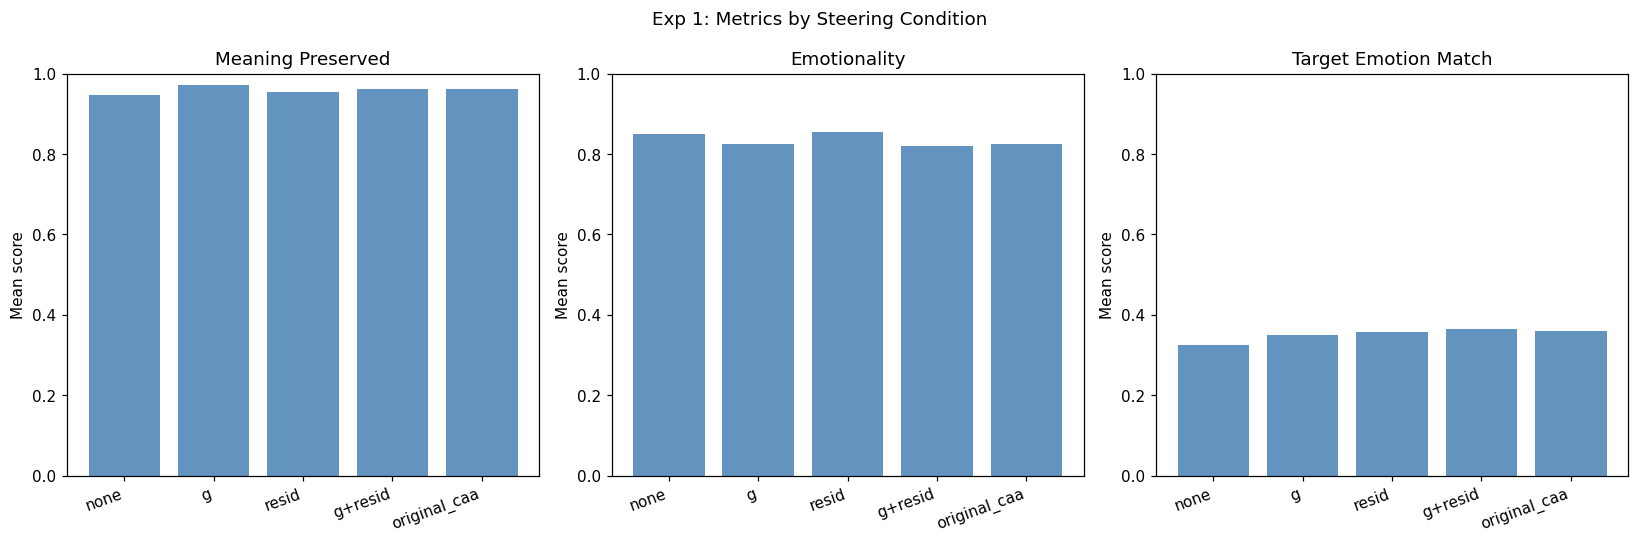

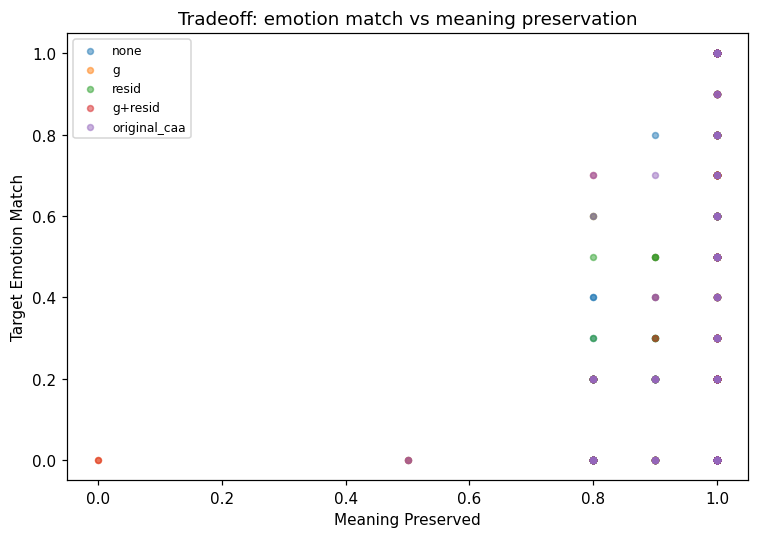

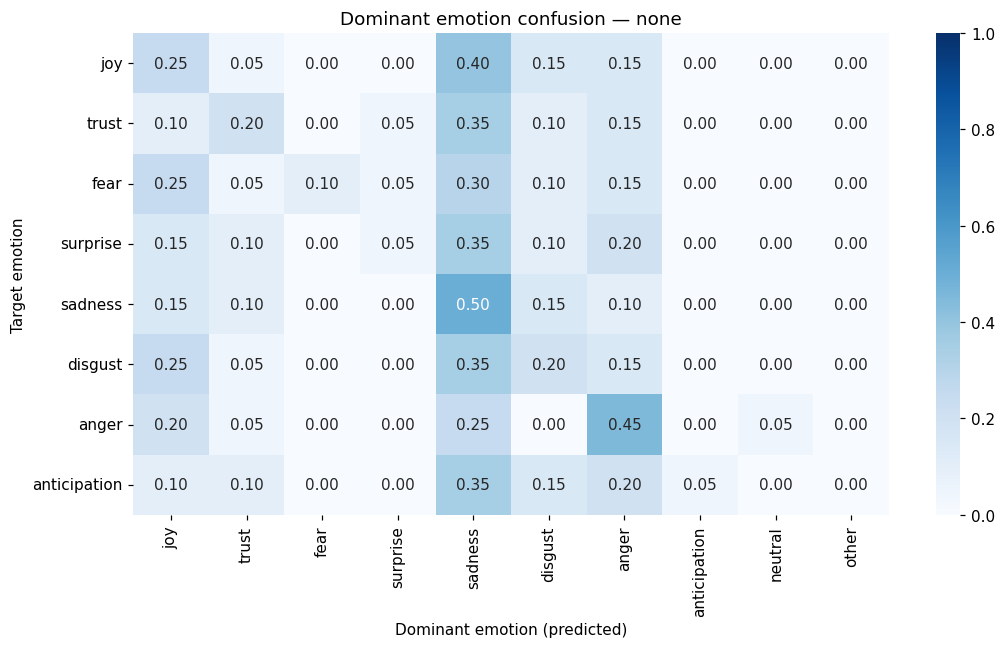

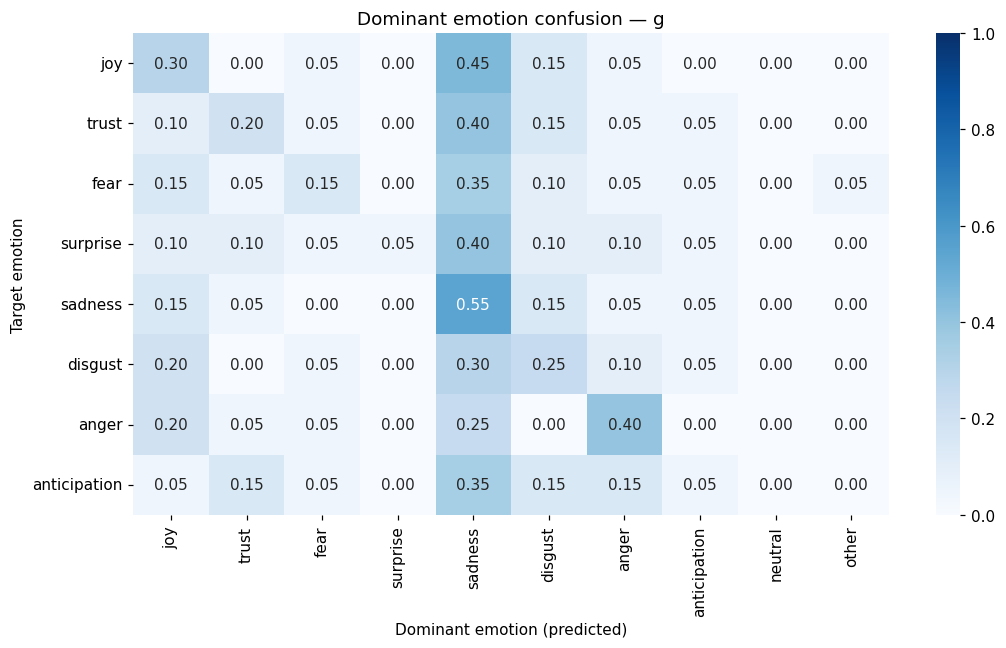

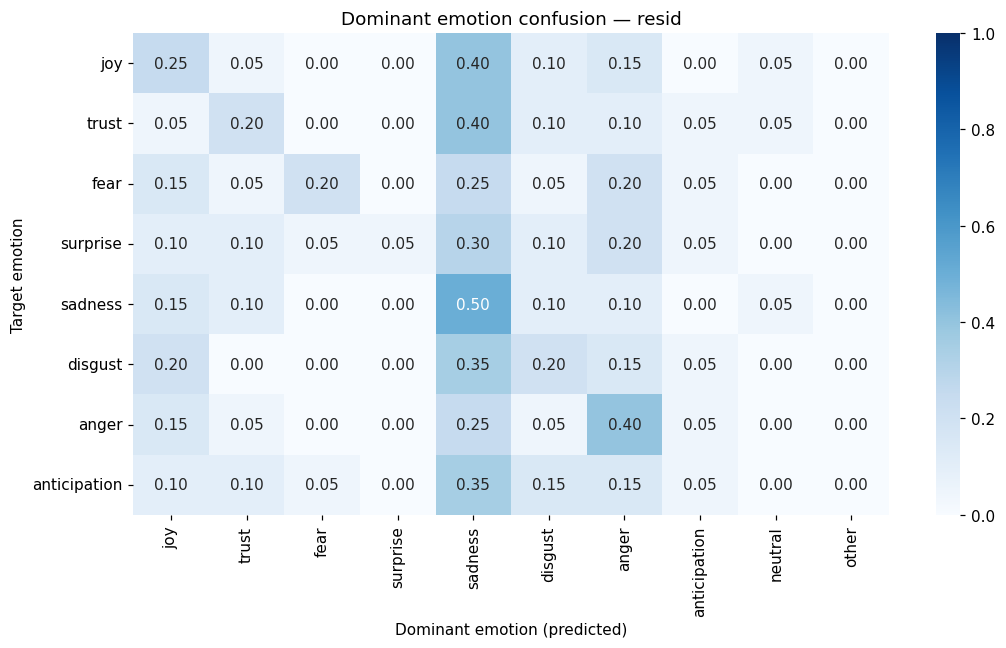

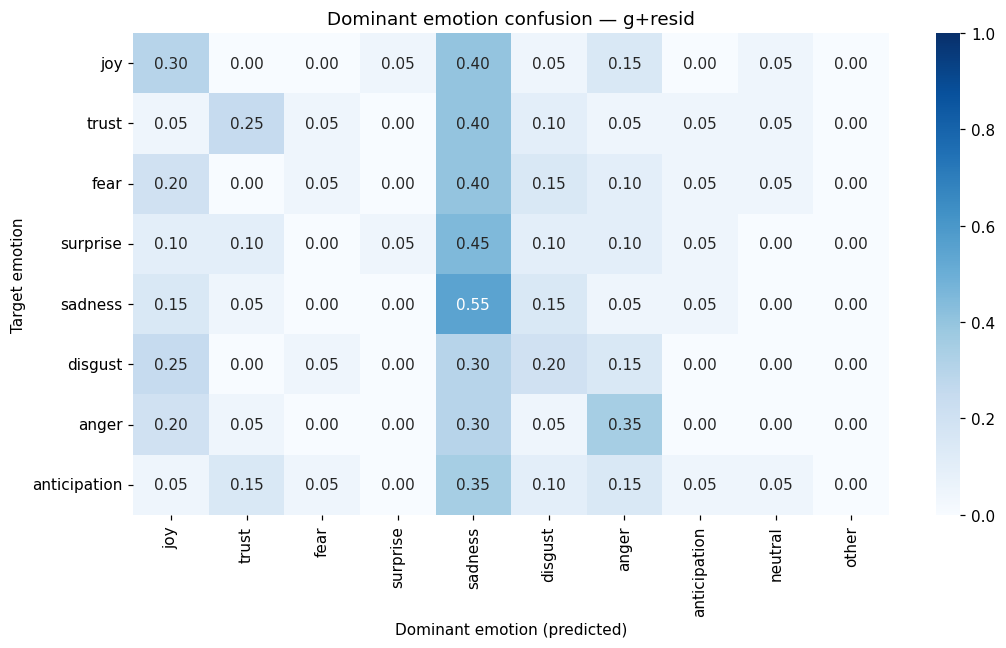

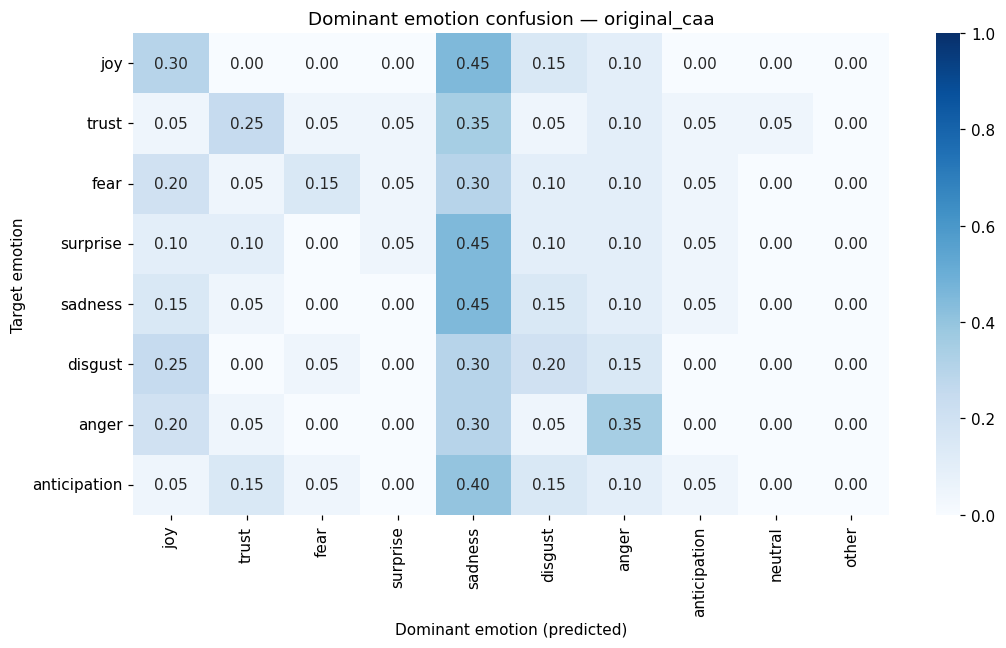

Plots saved.


In [33]:
# ── Guard: skip if no eval results ───────────────────────────────────────────
if not EVAL_RESULTS_FILE.exists() or eval_df is None:
    print('No eval results found. Run the LLM evaluator batch first, then re-run this cell.')
else:
    COND_ORDER  = ['none', 'g', 'resid', 'g+resid', 'original_caa']
    METRIC_COLS = ['meaning_preserved', 'emotionality', 'target_emotion_match']

    # ── Summary by condition ────────────────────────────────────────────────────
    summary_cond = (
        eval_df.groupby('steering_condition')[METRIC_COLS].mean().round(3)
        .reindex(COND_ORDER)
    )
    summary_cond.to_csv(OUT_DIR / 'summary_by_condition.csv')
    display(summary_cond)

    # ── Summary by emotion ──────────────────────────────────────────────────────
    summary_emo = (
        eval_df.groupby(['target_emotion', 'steering_condition'])[METRIC_COLS].mean().round(3)
    )
    summary_emo.to_csv(OUT_DIR / 'summary_by_emotion.csv')

    # ── Bar plots: metrics by condition ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, metric in zip(axes, METRIC_COLS):
        vals = summary_cond[metric].values
        ax.bar(COND_ORDER, vals, color='steelblue', alpha=0.85)
        ax.set_title(metric.replace('_', ' ').title())
        ax.set_ylim(0, 1)
        ax.set_xticklabels(COND_ORDER, rotation=20, ha='right')
        ax.set_ylabel('Mean score')
    plt.suptitle('Exp 1: Metrics by Steering Condition')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'metrics_by_condition.png', bbox_inches='tight')
    plt.show()

    # ── Tradeoff scatter ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    for cond in COND_ORDER:
        sub = eval_df[eval_df['steering_condition'] == cond]
        ax.scatter(
            sub['meaning_preserved'], sub['target_emotion_match'],
            label=cond, alpha=0.5, s=15,
        )
    ax.set_xlabel('Meaning Preserved')
    ax.set_ylabel('Target Emotion Match')
    ax.set_title('Tradeoff: emotion match vs meaning preservation')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'tradeoff_scatter.png', bbox_inches='tight')
    plt.show()

    # ── Dominant emotion confusion matrix ─────────────────────────────────────
    EMOTION_LABELS = EMOTION_ORDER + ['neutral', 'other']
    for cond in COND_ORDER:
        sub = eval_df[eval_df['steering_condition'] == cond].copy()
        if 'dominant_emotion' not in sub.columns:
            continue
        ct = pd.crosstab(
            sub['target_emotion'], sub['dominant_emotion'],
            normalize='index',
        ).reindex(index=EMOTION_ORDER, columns=EMOTION_LABELS, fill_value=0)
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues', ax=ax, vmin=0, vmax=1)
        ax.set_title(f'Dominant emotion confusion — {cond}')
        ax.set_xlabel('Dominant emotion (predicted)')
        ax.set_ylabel('Target emotion')
        plt.tight_layout()
        plt.savefig(OUT_DIR / f'confusion_{cond}.png', bbox_inches='tight')
        plt.show()

    print('Plots saved.')

In [34]:
# ── Multiplier sweep heatmaps (run after sweep eval results available) ─────────
SWEEP_EVAL_RESULTS = OUT_DIR / 'sweep_eval_results.jsonl'

if not SWEEP_EVAL_RESULTS.exists():
    print('No sweep eval results found.')
else:
    sweep_eval_rows = []
    with open(SWEEP_EVAL_RESULTS) as f:
        for line in f:
            result = json.loads(line)
            custom_id = result.get('custom_id', '')
            meta_idx  = int(custom_id.split('_')[1])
            meta      = sweep_eval_reqs[meta_idx]['_meta']
            try:
                content = result['response']['body']['choices'][0]['message']['content']
                scores  = json.loads(content)
            except Exception as e:
                scores = {'meaning_preserved': None, 'emotionality': None,
                          'target_emotion_match': None}
            sweep_eval_rows.append({**meta, **scores})

    sweep_eval_df = pd.DataFrame(sweep_eval_rows)
    sweep_eval_df['alpha_g']     = sweep_eval_df['alpha_g'].astype(float)
    sweep_eval_df['alpha_resid'] = sweep_eval_df['alpha_resid'].astype(float)

    sweep_summary = (
        sweep_eval_df.groupby(['target_emotion', 'alpha_g', 'alpha_resid'])
        [['meaning_preserved', 'emotionality', 'target_emotion_match']].mean()
        .reset_index()
    )
    sweep_summary.to_csv(OUT_DIR / 'multiplier_sweep_summary.csv', index=False)

    # ── Heatmaps per emotion for each metric ─────────────────────────────────
    for emo in EMOTION_ORDER:
        sub = sweep_summary[sweep_summary['target_emotion'] == emo]
        if sub.empty:
            continue
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for ax, metric in zip(axes, ['emotionality', 'target_emotion_match', 'meaning_preserved']):
            pivot = sub.pivot(index='alpha_resid', columns='alpha_g', values=metric)
            # Higher alpha_resid on y-axis top
            pivot = pivot.sort_index(ascending=False)
            sns.heatmap(
                pivot, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, cbar=True,
            )
            ax.set_title(f'{metric.replace("_"," ")} ({emo})')
            ax.set_xlabel('alpha_g  (g strength)')
            ax.set_ylabel('alpha_resid  (resid strength)')
        plt.suptitle(f'Multiplier sweep — {emo}', y=1.02)
        plt.tight_layout()
        plt.savefig(OUT_DIR / f'sweep_heatmap_{emo}.png', bbox_inches='tight')
        plt.show()

    print('Sweep heatmaps saved.')

No sweep eval results found.


In [35]:
# ── Final: write a quick markdown summary of vector norms ─────────────────────
README_PATH = OUT_DIR / 'README.md'

md = [
    '# CAA Decomposition Steering — Results Summary\n',
    f'Primary layer: {PRIMARY_LAYER}\n',
    f'Sample size: {len(held_out)}\n\n',
    '## Vector norms at layer ' + str(PRIMARY_LAYER) + '\n',
    f'| emotion | ||c_e|| | c_e·g | ||resid_raw|| |\n',
    f'|---------|--------|-------|------------|\n',
]
for ei, emo in enumerate(EMOTION_ORDER):
    md.append(
        f'| {emo:<14} | {np.linalg.norm(C[ei]):.4f} | '
        f'{float(C[ei] @ g):.4f} | {np.linalg.norm(resid_raw[ei]):.4f} |\n'
    )

md += [
    '\n## Output files\n',
    '- `generation_outputs.jsonl` — Exp 1 raw generations\n',
    '- `generation_eval_requests.jsonl` — LLM eval batch (submit to OpenAI)\n',
    '- `generation_eval_results.jsonl` — LLM eval results (after batch)\n',
    '- `summary_by_condition.csv` — Exp 1 metrics aggregated by condition\n',
    '- `summary_by_emotion.csv` — Exp 1 metrics by emotion × condition\n',
    '- `multiplier_sweep_outputs.jsonl` — Exp 3 sweep generations\n',
    '- `multiplier_sweep_summary.csv` — Exp 3 metrics (after eval)\n',
    '- `sweep_heatmap_{emotion}.png` — Exp 3 2D control surface heatmaps\n',
    '- `local_pc_generation_outputs.jsonl` — Exp 4 PC± generations\n',
    '- `local_pc_axis_interpretation_requests.jsonl` — Exp 4 LLM axis labelling batch\n',
    '- `local_pc_axis_interpretations.json` — Exp 4 axis labels (after batch)\n',
    '- `local_pc_axis_summary.md` — Exp 4 human-readable axis labels\n',
    '- `exp5_prompt_vs_steering.jsonl` — Exp 5 prompt vs steering generations\n',
    '- `metrics_by_condition.png`, `tradeoff_scatter.png`, `confusion_*.png`\n',
    '\n## Questions to answer\n',
    '1. What does `g` do during generation?\n',
    '2. What does `resid_e` do during generation?\n',
    '3. Is `g + resid_e` better controlled than original CAA?\n',
    '4. Which emotions are easiest / hardest to steer?\n',
    '5. Do local PCs produce consistent, interpretable sub-emotion changes?\n',
    '6. Which local PCs are promising as EmotionEngine DJ knobs?\n',
    '7. What steering recipe should be used in the next prototype?\n',
]

with open(README_PATH, 'w') as f:
    f.writelines(md)
print(f'README → {README_PATH}')

README → /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/steering_decomposition/README.md
